# Cell Count

In [9]:
import pandas as pd
from analyses.data_readers.recording_metadata_reader import RecordingMetadataReader
sig_cells = pd.read_excel('/home/connorlab/Documents/GitHub/Julie/Cortana/Ed and ANOVA/used_for_R01/zombies_all_anova_passed_cells--used for grant.xlsx')

In [10]:
prelim = RecordingMetadataReader().get_metadata_for_preliminary_analysis()
prelim.head()

,Date,Round No.,Location
0,2023-09-26,1,AMG
1,2023-09-26,2,AMG
2,2023-09-26,3,AMG
3,2023-09-28,1,AMG
4,2023-09-29,2,AMG


In [3]:
# merge
merged_df = pd.merge(sig_cells, prelim, on=['Date','Round No.'], how='left', indicator=True)

In [4]:
merged_df['NeuronID'] = (
        merged_df['Location'].astype(str) + "_" +
        merged_df['Date'].astype(str) + "_" +
        merged_df['Round No.'].astype(str) + "_" +
        merged_df['Cell'].astype(str)
)

In [5]:
unique_neurons = merged_df['NeuronID'].unique()
print(len(unique_neurons))

59


In [6]:
neuron_list= list(unique_neurons)
amg_neuron_count = sum(1 for neuron in neuron_list if neuron.startswith('AMG'))
er_neuron_count = sum(1 for neuron in neuron_list if neuron.startswith('ER'))
uncertain_neuron_count = sum(1 for neuron in neuron_list if neuron.startswith('na'))
print(amg_neuron_count)
print(er_neuron_count)
print(uncertain_neuron_count)

36
20
3


# Chi-Square test to examine whether the distribution of sig neurons across anatomical locations differ between groups (BestFrans vs Zombies) and (AMG vs ER)

In [7]:
with open('/home/connorlab/Documents/GitHub/Julie/Cortana/Ed and ANOVA/used_for_R01/bestfrans_neuron_list_with_location.csv', 'r') as f:
    bf_cells_with_loc = [line.strip() for line in f]
with open('/home/connorlab/Documents/GitHub/Julie/Cortana/Ed and ANOVA/used_for_R01/zombies_neuron_list_with_location.csv', 'r') as f:
    zom_cells_with_loc = [line.strip() for line in f]

In [8]:
bf_cells_with_loc

['Amygdala_2023-09-26_3_Channel.C_027_Unit 1',
 'Amygdala_2023-09-29_3_Channel.C_029_Unit 1',
 'Amygdala_2023-10-03_4_Channel.C_010_Unit 1',
 'Amygdala_2023-10-03_4_Channel.C_025_Unit 2',
 'Amygdala_2023-10-04_2_Channel.C_009_Unit 1',
 'Amygdala_2023-10-04_2_Channel.C_009_Unit 2',
 'Amygdala_2023-10-04_3_Channel.C_009_Unit 1',
 'Amygdala_2023-10-09_3_Channel.C_024',
 'Amygdala_2023-10-10_2_Channel.C_010',
 'Amygdala_2023-10-10_2_Channel.C_022',
 'Amygdala_2023-10-10_3_Channel.C_022',
 'Amygdala_2023-10-11_3_Channel.C_024',
 'ER_2023-10-27_3_Channel.C_015',
 'ER_2023-11-20_2_Channel.C_009',
 'ER_2023-11-22_2_Channel.C_009',
 'ER_2023-11-22_3_Channel.C_027',
 'ER_2023-11-22_3_Channel.C_028',
 'ER_2023-11-25_1_Channel.C_009',
 'ER_2023-11-25_1_Channel.C_017',
 'ER_2023-11-25_2_Channel.C_016',
 'ER_2023-11-25_3_Channel.C_018',
 'ER_2023-11-27_3_Channel.C_002',
 'ER_2023-11-27_3_Channel.C_017',
 'ER_2023-11-28_3_Channel.C_009',
 'ER_2023-11-28_4_Channel.C_015',
 'ER_2023-12-11_4_Channel.C_0

In [61]:
from collections import Counter

def count_regions(cell_list):
    region_labels = []
    for cell in cell_list:
        if cell.lower().startswith('amygdala'):
            region_labels.append('Amygdala')
        elif cell.lower().startswith('er'):
            region_labels.append('Entorhinal')
    return Counter(region_labels)

bf_counts = count_regions(bf_cells_with_loc)
zom_counts = count_regions(zom_cells_with_loc)

In [66]:
data = pd.DataFrame({
    'BestFrans': [bf_counts.get('Amygdala', 0), bf_counts.get('Entorhinal', 0)],
    'Zombies': [zom_counts.get('Amygdala', 0), zom_counts.get('Entorhinal', 0)]
}, index=['Amygdala', 'Entorhinal'])

data

,BestFrans,Zombies
Amygdala,12,36
Entorhinal,22,20


In [67]:
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(data)
print(f"Chi² = {chi2:.3f}, p = {p:.4f}")

Chi² = 6.027, p = 0.0141


## Best Frans Cells

In [13]:
bf_cells = pd.read_excel('/home/connorlab/Documents/GitHub/Julie/Cortana/Ed and ANOVA/used_for_R01/bestfrans_anova_passed_cells_old -- used for grant.xlsx')
bf_cells.head()

,Unnamed: 0,F-statistic,p-value,Date,Round No.,Cell,Time Window
0,47,3.282644,0.027,2023-09-26,3,Channel.C_027_Unit 1,"(250, 450)"
1,89,3.152212,0.016,2023-09-29,3,Channel.C_029_Unit 1,"(400, 550)"
2,134,2.706827,0.037,2023-10-03,4,Channel.C_010_Unit 1,"(100, 650)"
3,148,3.512962,0.017,2023-10-03,4,Channel.C_025_Unit 2,"(850, 950)"
4,171,2.686364,0.038,2023-10-04,2,Channel.C_009_Unit 1,"(200, 400)"


In [14]:
# Some steps deleted here
# Compute the cell count... with location
# save as csv files

### Here, just read it off from csv files

In [16]:
from collections import Counter
import csv

with open('../Cortana/Ed and ANOVA/used_for_R01/zombies_neuron_list_with_location.csv', 'r') as f:
    zombies_neuron_list = [line.strip() for line in f if line.strip()]
print(len(zombies_neuron_list))
amg_neuron_count = sum(1 for neuron in zombies_neuron_list if neuron.startswith('Amygdala'))
er_neuron_count = sum(1 for neuron in zombies_neuron_list if neuron.startswith('ER'))
uncertain_neuron_count = sum(1 for neuron in zombies_neuron_list if neuron.startswith('na'))
print(amg_neuron_count)
print(er_neuron_count)
print(uncertain_neuron_count)

56
36
20
0


In [18]:
import pandas as pd
# Extract Date and Round No
date_rounds = [(s.split('_')[1], s.split('_')[2]) for s in zombies_neuron_list]

# Count occurrences
counter = Counter(date_rounds)

# Convert to DataFrame
zombies_round_count_df = pd.DataFrame([
    {'Date': date, 'Round No.': round_no, 'Zombies': count}
    for (date, round_no), count in counter.items()
])

# Optional: sort by date and round
zombies_round_count_df = zombies_round_count_df.sort_values(by=['Date', 'Round No.']).reset_index(drop=True)

In [20]:
with open('../Cortana/Ed and ANOVA/used_for_R01/bestfrans_neuron_list_with_location.csv', 'r') as f:
    bf_neuron_list = [line.strip() for line in f if line.strip()]
amg_neuron_count = sum(1 for neuron in bf_neuron_list if neuron.startswith('Amygdala'))
er_neuron_count = sum(1 for neuron in bf_neuron_list if neuron.startswith('ER'))
uncertain_neuron_count = sum(1 for neuron in bf_neuron_list if neuron.startswith('na'))
print(amg_neuron_count)
print(er_neuron_count)
print(uncertain_neuron_count)

12
22
0


In [26]:
date_rounds = [(s.split('_')[1], s.split('_')[2]) for s in bf_neuron_list]

# Count occurrences
counter = Counter(date_rounds)

# Convert to DataFrame
bf_round_count_df = pd.DataFrame([
    {'Date': date, 'Round No.': round_no, 'BestFrans': count}
    for (date, round_no), count in counter.items()
])

# Optional: sort by date and round
bf_round_count_df = bf_round_count_df.sort_values(by=['Date', 'Round No.']).reset_index(drop=True)

In [27]:
# merge count for best frans and zombies
round_count_merged = pd.merge(bf_round_count_df, zombies_round_count_df, on=['Date', 'Round No.'], how='outer')
round_count_merged.fillna(0, inplace=True)
round_count_merged[['BestFrans', 'Zombies']] = round_count_merged[['BestFrans', 'Zombies']].astype(int)
round_count_merged.head()

,Date,Round No.,BestFrans,Zombies
0,2023-09-26,3,1,3
1,2023-09-29,3,1,0
2,2023-10-03,4,2,3
3,2023-10-04,2,2,2
4,2023-10-04,3,1,4


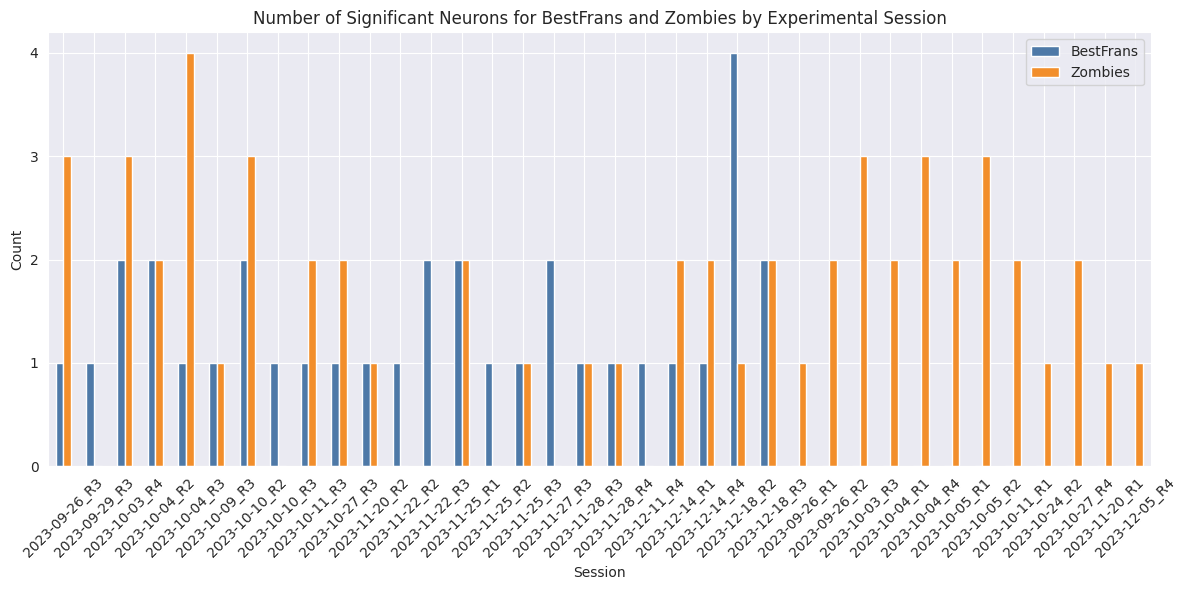

In [28]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
%matplotlib inline
round_count_merged['Session'] = round_count_merged['Date'] + '_R' + round_count_merged['Round No.'].astype(str)
df_plot = round_count_merged.set_index('Session')[['BestFrans', 'Zombies']]

df_plot.plot(kind='bar', figsize=(12, 6), color=['#4e79a7', '#f28e2b'])
plt.ylabel('Count')
plt.title('Number of Significant Neurons for BestFrans and Zombies by Experimental Session')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

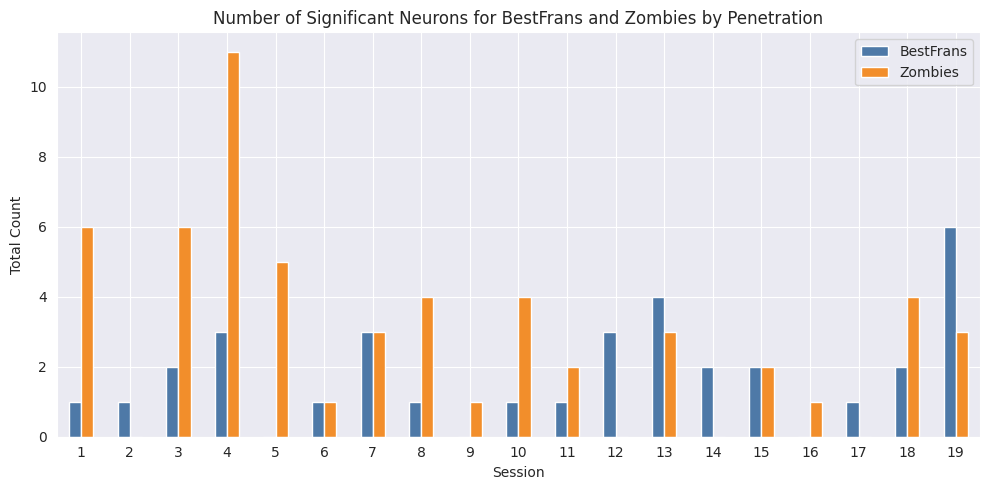

In [76]:
# Date 기준으로 합산
df_grouped = round_count_merged.groupby('Date')[['BestFrans', 'Zombies']].sum().reset_index()
df_grouped[['BestFrans', 'Zombies']] = df_grouped[['BestFrans', 'Zombies']].astype(int)
# df_grouped.set_index('Date').plot(
#     kind='bar',
#     figsize=(10, 5),
#     color=['#4e79a7', '#f28e2b']  # BestFrans, Zombies
# )
df_grouped['Session'] = list(range(1, len(df_grouped) + 1))

df_grouped.set_index('Session')[['BestFrans', 'Zombies']].plot(
    kind='bar',
    figsize=(10, 5),
    color=['#4e79a7', '#f28e2b']
)

plt.ylabel('Total Count')
plt.title('Number of Significant Neurons for BestFrans and Zombies by Penetration')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Chi-Square Test for Significance

### Total Cell Count

In [81]:
# Total cell count
df_grouped['Total'] = df_grouped['BestFrans'] + df_grouped['Zombies']
from scipy.stats import chisquare
import numpy as np

observed = df_grouped['Total'].values.astype(float)
expected = np.full(len(observed), observed.mean())

chi2, p = chisquare(f_obs=observed, f_exp=expected)
print(f"Chi² = {chi2:.3f}, p = {p:.4f}")


Chi² = 43.422, p = 0.0007


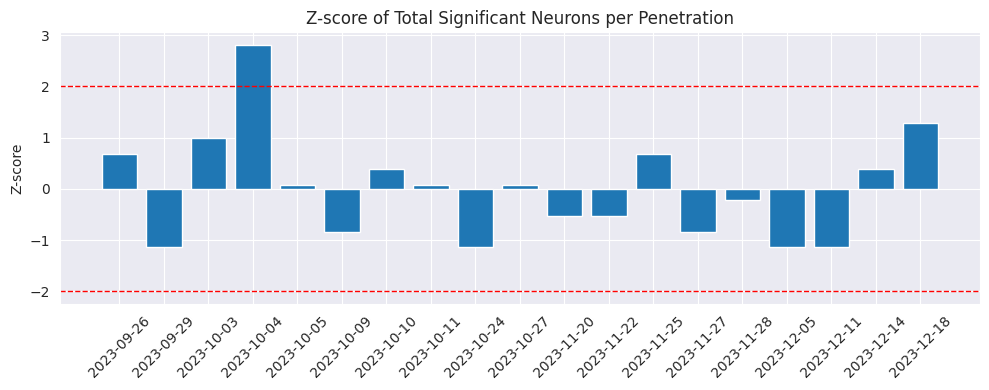

In [35]:
# z score for total cell count
z_scores = (observed - observed.mean()) / observed.std()
df_grouped['Z'] = z_scores

plt.figure(figsize=(10, 4))
plt.bar(df_grouped['Date'], df_grouped['Z'])
plt.axhline(2, color='r',linewidth = 1, linestyle='--')
plt.axhline(-2, color='r',linewidth = 1, linestyle='--')
plt.title("Z-score of Total Significant Neurons per Penetration")
plt.ylabel("Z-score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bonferroni-corrected Z threshold (α = 0.05, n = 19): 2.790


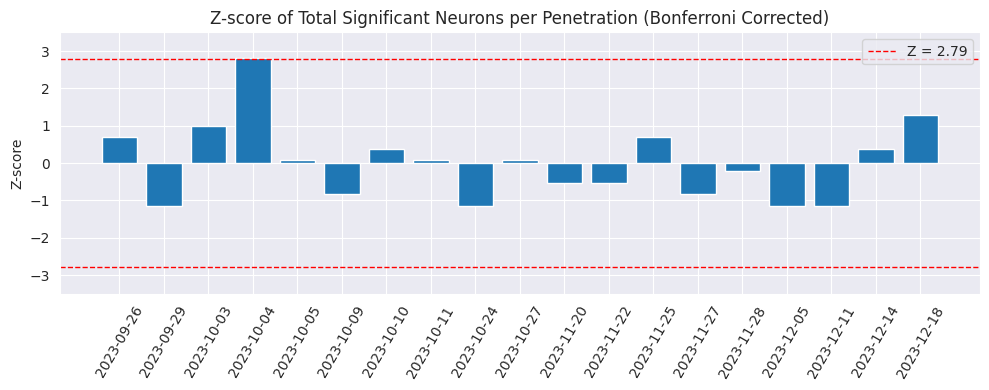

0     0.687846
1    -1.135746
2     0.991778
3     2.815369
4     0.079982
5    -0.831814
6     0.383914
7     0.079982
8    -1.135746
9     0.079982
10   -0.527882
11   -0.527882
12    0.687846
13   -0.831814
14   -0.223950
15   -1.135746
16   -1.135746
17    0.383914
18    1.295710
Name: Z, dtype: float64


In [37]:
from scipy.stats import norm
# Bonferroni corrected Z-score for Total Count
n_dates = len(df_grouped)
alpha = 0.05
z_threshold = norm.ppf(1 - alpha / n_dates)

print(f"Bonferroni-corrected Z threshold (α = {alpha}, n = {n_dates}): {z_threshold:.3f}")

# Plot with corrected threshold
plt.figure(figsize=(10, 4))
plt.bar(df_grouped['Date'], df_grouped['Z'])
plt.axhline(z_threshold, color='r', linewidth = 1, linestyle='--', label=f'Z = {z_threshold:.2f}')
plt.axhline(-z_threshold, color='r',linewidth = 1, linestyle='--')
plt.ylim(-3.5,3.5)
plt.title("Z-score of Total Significant Neurons per Penetration (Bonferroni Corrected)")
plt.ylabel("Z-score")
plt.xticks(rotation=60)
plt.legend()
plt.tight_layout()
plt.show()
print(df_grouped['Z'])

### Zombies

In [38]:
# Chi-square for Zombies
zom_observed = df_grouped['Zombies'].values.astype(float)
zom_expected = np.full(len(zom_observed), zom_observed.mean())

zom_chi2, zom_p = chisquare(f_obs=zom_observed, f_exp=zom_expected)
print(f"Chi² = {zom_chi2:.3f}, p = {zom_p:.4f}")

Chi² = 47.143, p = 0.0002


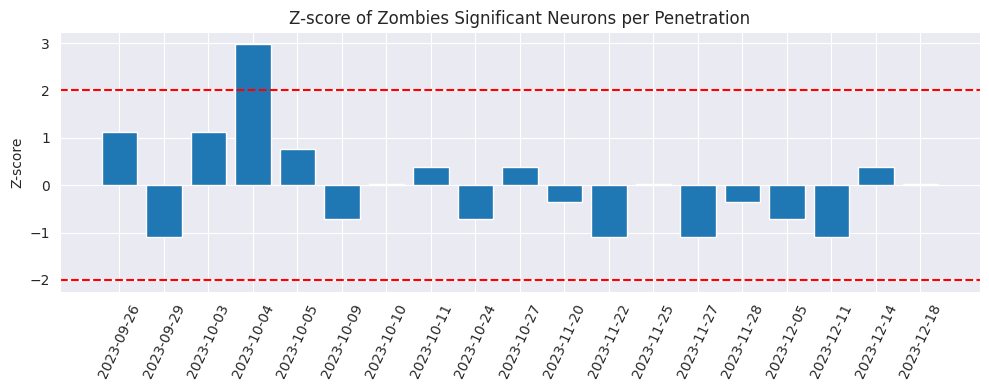

In [39]:
zom_z_scores = (zom_observed - zom_observed.mean()) / zom_observed.std()
df_grouped['Zombies_Z'] = zom_z_scores

plt.figure(figsize=(10, 4))
plt.bar(df_grouped['Date'], df_grouped['Zombies_Z'])
plt.axhline(2, color='r', linestyle='--')
plt.axhline(-2, color='r', linestyle='--')
plt.title("Z-score of Zombies Significant Neurons per Penetration")
plt.ylabel("Z-score")
plt.xticks(rotation=65)
plt.tight_layout()
plt.show()

Bonferroni-corrected Z threshold (α = 0.05, n = 19): 2.790


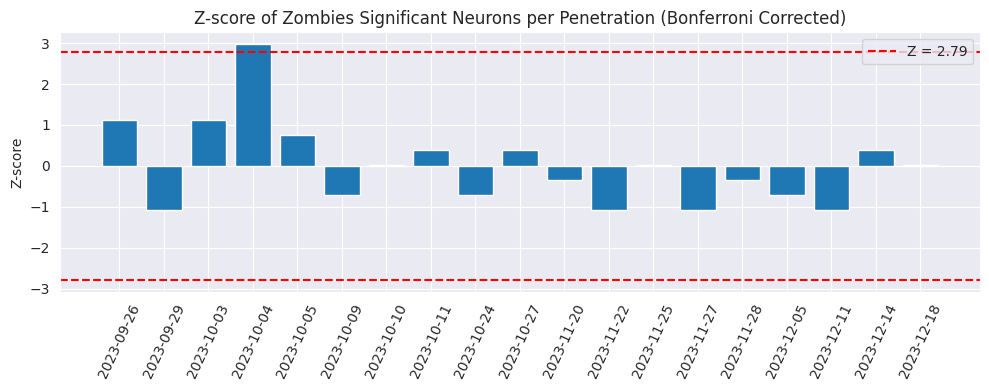

In [40]:
n_dates = len(df_grouped)
alpha = 0.05
z_threshold = norm.ppf(1 - alpha / n_dates)

print(f"Bonferroni-corrected Z threshold (α = {alpha}, n = {n_dates}): {z_threshold:.3f}")

# Plot with corrected threshold
plt.figure(figsize=(10, 4))
plt.bar(df_grouped['Date'], df_grouped['Zombies_Z'])
plt.axhline(z_threshold, color='r', linestyle='--', label=f'Z = {z_threshold:.2f}')
plt.axhline(-z_threshold, color='r', linestyle='--')
plt.title("Z-score of Zombies Significant Neurons per Penetration (Bonferroni Corrected)")
plt.ylabel("Z-score")
plt.xticks(rotation=65)
plt.legend()
plt.tight_layout()
plt.show()

### Best Frans

In [43]:
# Chi-square for Best Frans
bf_observed = df_grouped['BestFrans'].values.astype(float)
bf_expected = np.full(len(bf_observed), bf_observed.mean())
bf_chi2, bf_p = chisquare(f_obs=bf_observed, f_exp=bf_expected)
print(f"Chi² = {bf_chi2:.3f}, p = {bf_p:.4f}")

Chi² = 23.000, p = 0.1906


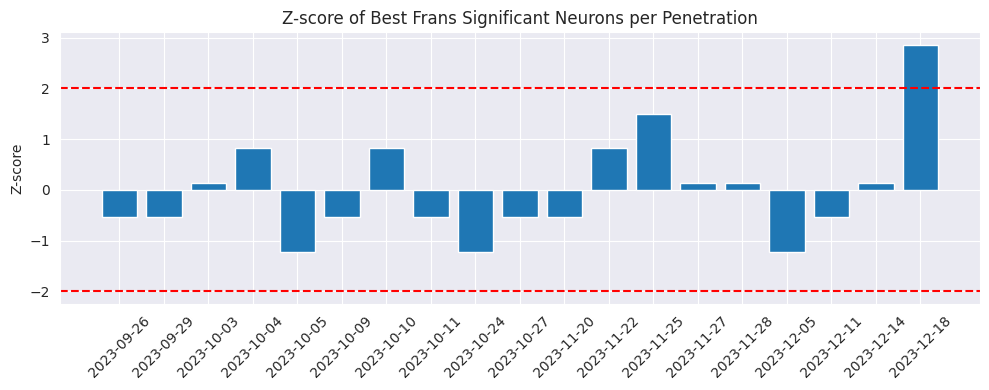

In [45]:
bf_z_scores = (bf_observed - bf_observed.mean()) / bf_observed.std()
df_grouped['BestFrans_Z'] = bf_z_scores

plt.figure(figsize=(10, 4))
plt.bar(df_grouped['Date'], df_grouped['BestFrans_Z'])
plt.axhline(2, color='r', linestyle='--')
plt.axhline(-2, color='r', linestyle='--')
plt.title("Z-score of Best Frans Significant Neurons per Penetration")
plt.ylabel("Z-score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bonferroni-corrected Z threshold (α = 0.05, n = 19): 2.790


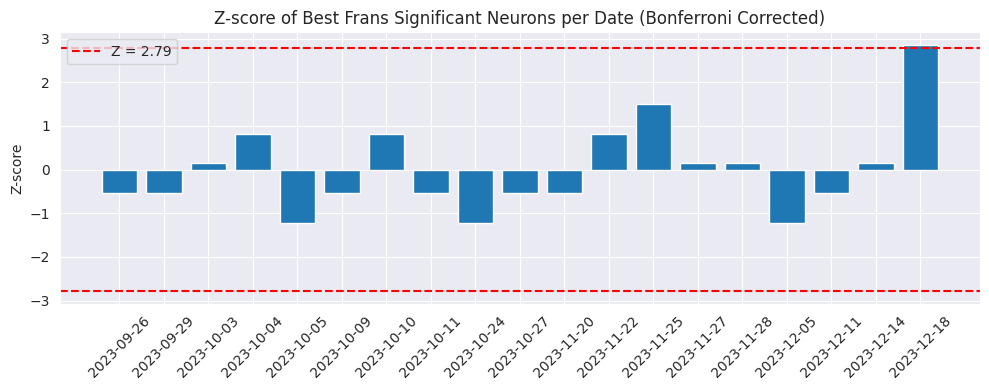

In [46]:
n_dates = len(df_grouped)
alpha = 0.05
z_threshold = norm.ppf(1 - alpha / n_dates)

print(f"Bonferroni-corrected Z threshold (α = {alpha}, n = {n_dates}): {z_threshold:.3f}")

# Plot with corrected threshold
plt.figure(figsize=(10, 4))
plt.bar(df_grouped['Date'], df_grouped['BestFrans_Z'])
plt.axhline(z_threshold, color='r', linestyle='--', label=f'Z = {z_threshold:.2f}')
plt.axhline(-z_threshold, color='r', linestyle='--')
plt.title("Z-score of Best Frans Significant Neurons per Date (Bonferroni Corrected)")
plt.ylabel("Z-score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Permutation Test

          Date  Total  Permutation_p  Significant (p<0.05)
0   2023-09-26      7       0.068186                 False
1   2023-09-29      1       1.000000                 False
2   2023-10-03      8       0.073585                 False
3   2023-10-04     14       0.000400                  True
4   2023-10-05      5       0.170166                 False
5   2023-10-09      2       0.947810                 False
6   2023-10-10      6       0.571686                 False
7   2023-10-11      5       0.324935                 False
8   2023-10-24      1       0.952010                 False
9   2023-10-27      5       0.342931                 False
10  2023-11-20      3       0.801040                 False
11  2023-11-22      3       1.000000                 False
12  2023-11-25      7       0.573485                 False
13  2023-11-27      2       1.000000                 False
14  2023-11-28      4       0.799440                 False
15  2023-12-05      1       0.949610                 Fal

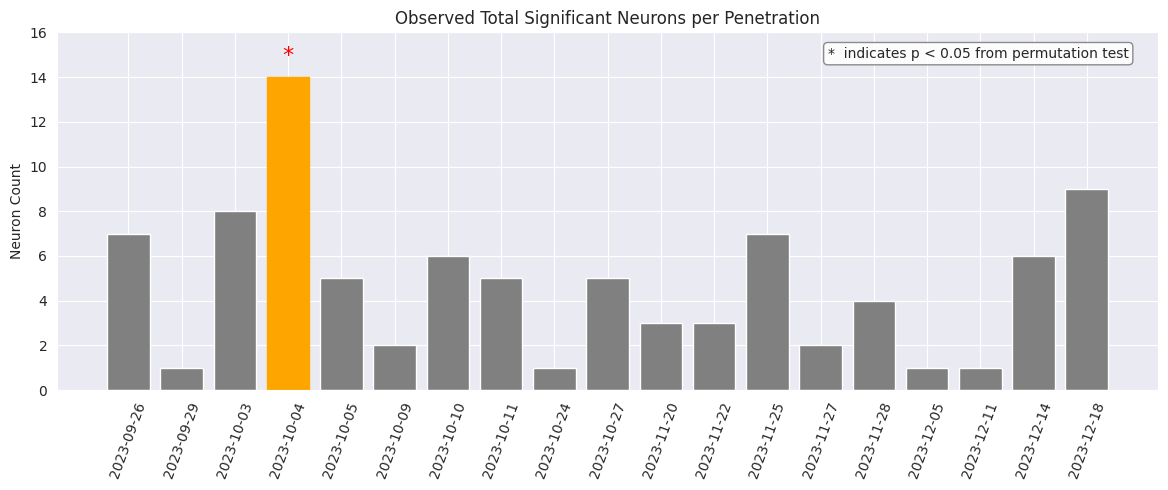

In [47]:

# Assume this is your real count per date
dates = df_grouped['Date']
real_counts = df_grouped['Zombies'].values
n_dates = len(real_counts)
total_neurons = int(real_counts.sum())

# Number of permutations
n_perm = 5000
perm_results = np.zeros((n_perm, n_dates))

# Run permutations
for i in range(n_perm):
    # Randomly assign total_neurons to dates
    permuted = np.random.choice(n_dates, size=total_neurons, replace=True)
    # print(permuted)
    counts = np.bincount(permuted, minlength=n_dates)
    perm_results[i] = counts

# Compute p-values per date
p_values = []
for i in range(n_dates):
    greater = np.sum(perm_results[:, i] >= real_counts[i])
    p = (greater + 1) / (n_perm + 1)  # +1 smoothing
    p_values.append(p)

df_grouped['Permutation_p'] = p_values

# Optional: Mark significant dates
df_grouped['Significant (p<0.05)'] = df_grouped['Permutation_p'] < 0.05

# Show significant dates
print(df_grouped[['Date', 'Total', 'Permutation_p', 'Significant (p<0.05)']])
import matplotlib.pyplot as plt

# Bar plot with stars for p < 0.05
plt.figure(figsize=(12, 5))
bars = plt.bar(df_grouped['Date'], df_grouped['Total'], color='gray')

# Highlight significant bars
for i, (pval, count) in enumerate(zip(df_grouped['Permutation_p'], df_grouped['Total'])):
    if pval < 0.05:
        bars[i].set_color('orange')
        plt.text(i, count + 0.5, '*', ha='center', va='bottom', fontsize=16, color='red')

plt.title("Observed Total Significant Neurons per Penetration")
plt.ylabel("Neuron Count")
plt.xticks(rotation=70)
plt.ylim(0, 16)
textstr = "*  indicates p < 0.05 from permutation test"
props = dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9)
plt.gca().text(0.7, 0.96, textstr, transform=plt.gca().transAxes,
               fontsize=10, verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

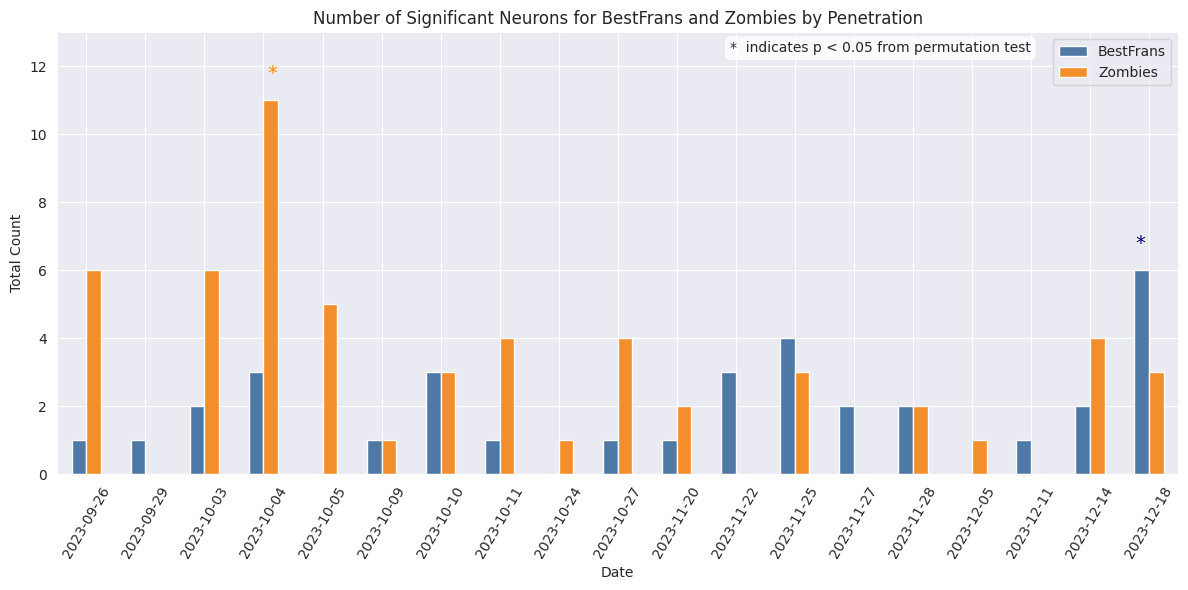

In [48]:

df_grouped = round_count_merged.groupby('Date')[['BestFrans', 'Zombies']].sum().reset_index()
df_grouped[['BestFrans', 'Zombies']] = df_grouped[['BestFrans', 'Zombies']].astype(int)

n_dates = len(df_grouped)
n_perm = 5000

# Helper function for one condition
def permutation_test_per_condition(real_counts, n_dates, n_perm=5000):
    total = int(real_counts.sum())
    perm_results = np.zeros((n_perm, n_dates))
    for i in range(n_perm):
        permuted = np.random.choice(n_dates, size=total, replace=True)
        counts = np.bincount(permuted, minlength=n_dates)
        perm_results[i] = counts
    p_values = []
    for i in range(n_dates):
        greater = np.sum(perm_results[:, i] >= real_counts[i])
        p = (greater + 1) / (n_perm + 1)
        p_values.append(p)
    return np.array(p_values)

# Run separately for each condition
p_bestfrans = permutation_test_per_condition(df_grouped['BestFrans'].values, n_dates, n_perm)
p_zombies = permutation_test_per_condition(df_grouped['Zombies'].values, n_dates, n_perm)

# Save to dataframe
df_grouped['BestFrans_p'] = p_bestfrans
df_grouped['Zombies_p'] = p_zombies

df_grouped_plot = df_grouped.set_index('Date')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = df_grouped_plot[['BestFrans', 'Zombies']].plot(
    kind='bar',
    ax=ax,
    color=['#4e79a7', '#f28e2b'],
    legend=True
)

plt.ylabel('Total Count')
plt.title('Number of Significant Neurons for BestFrans and Zombies by Penetration')
plt.xticks(rotation=60)
ymax = max(df_grouped['BestFrans'].max(), df_grouped['Zombies'].max())
plt.ylim(0, ymax + 2)
textstr = "*  indicates p < 0.05 from permutation test"
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax.text(0.6, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
# Add asterisks per bar if p < 0.05
for i, (bf_val, z_val, p_bf, p_z) in enumerate(zip(
        df_grouped['BestFrans'], df_grouped['Zombies'],
        df_grouped['BestFrans_p'], df_grouped['Zombies_p'])):

    if p_bf < 0.05:
        ax.text(i - 0.15, bf_val + 0.5, '*', ha='center', va='bottom', fontsize=14, color='navy')
    if p_z < 0.05:
        ax.text(i + 0.15, z_val + 0.5, '*', ha='center', va='bottom', fontsize=14, color='darkorange')

plt.tight_layout()
plt.show()
